# 08 — AML Pattern Analysis & Rule Extraction

Analyzes **WHY** transactions are flagged as suspicious:
1. **Amount Patterns** — transaction value thresholds
2. **Network Patterns** — structural characteristics (fan-out, fan-in, hubs)
3. **Frequency Patterns** — velocity, repetition
4. **Feature Importance** — what drives anomaly scores
5. **Combined Rules** — extracted detection rules

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch
from matplotlib.lines import Line2D
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from gan_anomaly import Generator, Encoder, anomaly_score as compute_anomaly_score

os.makedirs("results", exist_ok=True)
plt.style.use('default')
plt.rcParams['figure.figsize'] = [14, 8]
print("Setup complete!")

Setup complete!


In [2]:
# Load data
transactions = pd.read_parquet("data/transactions_processed.parquet")
node_features_raw = pd.read_parquet("data/node_features.parquet")
node_embeddings = pd.read_parquet("results/node_embeddings_scored.parquet")

# Load GAN for threshold
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with open("models/training_meta.json") as f:
    meta = json.load(f)
G_m = Generator(meta["latent_dim"], meta["input_dim"], meta["g_hidden"], meta["n_layers"], meta["activation"]).to(device)
E_m = Encoder(meta["input_dim"], meta["latent_dim"], meta["e_hidden"], meta["n_layers"], meta["activation"]).to(device)
G_m.load_state_dict(torch.load("models/generator.pt", map_location=device, weights_only=True))
E_m.load_state_dict(torch.load("models/encoder.pt", map_location=device, weights_only=True))
X_train = np.load("models/X_train.npy")
train_scores = compute_anomaly_score(torch.tensor(X_train, dtype=torch.float32).to(device), E_m, G_m).cpu().numpy()
threshold = np.percentile(train_scores, 99)

print(f"Loaded {len(transactions):,} transactions, {len(node_embeddings):,} nodes")
print(f"Anomalies: {node_embeddings['is_anomaly'].sum():,} ({100*node_embeddings['is_anomaly'].mean():.1f}%)")

Loaded 430,744 transactions, 7,500 nodes
Anomalies: 89 (1.2%)


In [3]:
# Build comprehensive node features
G = nx.from_pandas_edgelist(transactions, "source", "target", edge_attr="base_amt", create_using=nx.DiGraph())

node_features = node_embeddings[["id", "anomaly_score", "is_anomaly"]].copy()
if "is_sar" in node_embeddings.columns:
    node_features["is_sar"] = node_embeddings["is_sar"]

node_features["in_degree"] = node_features["id"].map(dict(G.in_degree())).fillna(0)
node_features["out_degree"] = node_features["id"].map(dict(G.out_degree())).fillna(0)
node_features["total_degree"] = node_features["in_degree"] + node_features["out_degree"]

out_amounts = transactions.groupby("source")["base_amt"].agg(["sum", "mean", "std", "min", "max", "count"])
out_amounts.columns = ["out_total", "out_mean", "out_std", "out_min", "out_max", "out_count"]
in_amounts = transactions.groupby("target")["base_amt"].agg(["sum", "mean", "std", "min", "max", "count"])
in_amounts.columns = ["in_total", "in_mean", "in_std", "in_min", "in_max", "in_count"]

node_features = node_features.merge(out_amounts, left_on="id", right_index=True, how="left")
node_features = node_features.merge(in_amounts, left_on="id", right_index=True, how="left")
node_features = node_features.fillna(0)

node_features["total_volume"] = node_features["out_total"] + node_features["in_total"]
node_features["net_flow"] = node_features["in_total"] - node_features["out_total"]
node_features["flow_ratio"] = node_features["out_total"] / (node_features["in_total"] + 1)
node_features["avg_txn_size"] = node_features["total_volume"] / (node_features["total_degree"] + 1)
node_features["txn_std"] = (node_features["out_std"].fillna(0) + node_features["in_std"].fillna(0)) / 2

unique_targets = transactions.groupby("source")["target"].nunique().rename("unique_targets")
unique_sources = transactions.groupby("target")["source"].nunique().rename("unique_sources")
node_features = node_features.merge(unique_targets, left_on="id", right_index=True, how="left")
node_features = node_features.merge(unique_sources, left_on="id", right_index=True, how="left")
node_features["unique_counterparties"] = node_features["unique_targets"].fillna(0) + node_features["unique_sources"].fillna(0)
node_features["fan_out_ratio"] = node_features["unique_targets"].fillna(0) / (node_features["out_count"] + 1)
node_features["fan_in_ratio"] = node_features["unique_sources"].fillna(0) / (node_features["in_count"] + 1)

print(f"Created {len(node_features.columns)} features for {len(node_features)} nodes")

Created 29 features for 7500 nodes


## 1. Amount Patterns

In [4]:
suspicious = node_features[node_features["is_anomaly"] == True]
normal = node_features[node_features["is_anomaly"] == False]

amount_features = ["total_volume", "avg_txn_size", "out_mean", "in_mean", "out_max", "in_max", "txn_std"]

print("=" * 80)
print(" AMOUNT PATTERN ANALYSIS: Suspicious vs Normal")
print("=" * 80)
print(f"\n{'Feature':<25} {'Suspicious Mean':>18} {'Normal Mean':>18} {'Ratio':>10} {'P-value':>12}")
print("-" * 80)

amount_rules = []
for feat in amount_features:
    susp_mean = suspicious[feat].mean()
    norm_mean = normal[feat].mean() if len(normal) > 0 else 0
    ratio = susp_mean / (norm_mean + 0.001)
    if len(normal) > 0 and len(suspicious) > 0:
        _, p_value = stats.mannwhitneyu(suspicious[feat], normal[feat], alternative="two-sided")
    else:
        p_value = 1.0
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"{feat:<25} ${susp_mean:>17,.2f} ${norm_mean:>17,.2f} {ratio:>9.2f}x {p_value:>10.4f} {sig}")

 AMOUNT PATTERN ANALYSIS: Suspicious vs Normal

Feature                      Suspicious Mean        Normal Mean      Ratio      P-value
--------------------------------------------------------------------------------
total_volume              $     4,046,764.37 $        13,817.30    292.88x     0.3362 
avg_txn_size              $         4,014.15 $           703.52      5.71x     0.0014 **
out_mean                  $           879.93 $           433.11      2.03x     0.0617 
in_mean                   $           970.42 $           544.33      1.78x     0.0268 *
out_max                   $         1,586.05 $           594.89      2.67x     0.0000 ***
in_max                    $         1,774.31 $           934.35      1.90x     0.0110 *
txn_std                   $           288.04 $           165.69      1.74x     0.6327 


In [5]:
# Extract amount-based rules
print("\n" + "=" * 60)
print(" EXTRACTED AMOUNT RULES")
print("=" * 60)

rules = []
for name, feat, pct, desc in [
    ("Total volume", "total_volume", 0.90, "High total transaction volume"),
    ("Avg transaction", "avg_txn_size", 0.90, "Large average transaction size"),
    ("Transaction std", "txn_std", 0.90, "High variance in amounts"),
    ("Max outgoing", "out_max", 0.95, "Very large single outgoing transaction"),
]:
    thr = node_features[feat].quantile(pct)
    rate = node_features[node_features[feat] > thr]["is_anomaly"].mean()
    rules.append({"rule": f"{name} > ${thr:,.0f}", "suspicious_rate": rate, "description": desc})
    print(f"\nRule: {name} > ${thr:,.0f}")
    print(f"   Suspicious Rate: {100*rate:.1f}%")
    print(f"   {desc}")


 EXTRACTED AMOUNT RULES

Rule: Total volume > $18,979
   Suspicious Rate: 5.6%
   High total transaction volume

Rule: Avg transaction > $1,078
   Suspicious Rate: 5.9%
   Large average transaction size

Rule: Transaction std > $279
   Suspicious Rate: 2.3%
   High variance in amounts

Rule: Max outgoing > $1,575
   Suspicious Rate: 10.4%
   Very large single outgoing transaction


## 2. Network/Structural Patterns

In [6]:
network_features = ["in_degree", "out_degree", "total_degree", "unique_counterparties", "fan_out_ratio", "fan_in_ratio"]

print("=" * 80)
print(" NETWORK PATTERN ANALYSIS")
print("=" * 80)
print(f"\n{'Feature':<25} {'Suspicious Mean':>18} {'Normal Mean':>18} {'Ratio':>10} {'P-value':>12}")
print("-" * 80)

for feat in network_features:
    susp_mean = suspicious[feat].mean()
    norm_mean = normal[feat].mean() if len(normal) > 0 else 0
    ratio = susp_mean / (norm_mean + 0.001)
    if len(normal) > 0:
        _, p_value = stats.mannwhitneyu(suspicious[feat], normal[feat], alternative="two-sided")
    else:
        p_value = 1.0
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"{feat:<25} {susp_mean:>18.2f} {norm_mean:>18.2f} {ratio:>9.2f}x {p_value:>10.4f} {sig}")

 NETWORK PATTERN ANALYSIS

Feature                      Suspicious Mean        Normal Mean      Ratio      P-value
--------------------------------------------------------------------------------
in_degree                             173.35               6.97     24.86x     0.0050 **
out_degree                            397.62               4.28     92.90x     0.0007 ***
total_degree                          570.97              11.25     50.74x     0.0942 
unique_counterparties                 570.97              11.25     50.74x     0.0942 
fan_out_ratio                           0.30               0.45      0.67x     0.0000 ***
fan_in_ratio                            0.35               0.57      0.61x     0.0000 ***


In [7]:
# Extract network rules
print("\n" + "=" * 60)
print(" EXTRACTED NETWORK RULES")
print("=" * 60)

network_rules = []
for feat, pct, pattern, desc in [
    ("unique_targets", 0.90, "STRUCTURING / LAYERING", "Sending to many unique recipients"),
    ("unique_sources", 0.90, "COLLECTION / AGGREGATION", "Receiving from many unique senders"),
    ("total_degree", 0.95, "HUB / CENTRAL NODE", "Highly connected node"),
]:
    thr = node_features[feat].quantile(pct)
    if thr > 0:
        rate = node_features[node_features[feat] > thr]["is_anomaly"].mean()
        network_rules.append({"rule": f"{feat} > {thr:.0f}", "suspicious_rate": rate, "pattern": pattern, "description": desc, "category": "NETWORK"})
        print(f"\nRule: {feat} > {thr:.0f}")
        print(f"   Pattern: {pattern}")
        print(f"   Suspicious Rate: {100*rate:.1f}%")

# Flow imbalance
node_features["flow_imbalance"] = abs(node_features["out_total"] - node_features["in_total"]) / (node_features["total_volume"] + 1)
imb_rate = node_features[node_features["flow_imbalance"] > 0.8]["is_anomaly"].mean()
network_rules.append({"rule": "Flow imbalance > 80%", "suspicious_rate": imb_rate, "pattern": "ONE-WAY FLOW", "description": "Mostly sending OR receiving", "category": "NETWORK"})
print(f"\nRule: Flow imbalance > 80%")
print(f"   Pattern: ONE-WAY FLOW")
print(f"   Suspicious Rate: {100*imb_rate:.1f}%")


 EXTRACTED NETWORK RULES

Rule: unique_targets > 10
   Pattern: STRUCTURING / LAYERING
   Suspicious Rate: 6.0%

Rule: unique_sources > 12
   Pattern: COLLECTION / AGGREGATION
   Suspicious Rate: 4.4%

Rule: total_degree > 36
   Pattern: HUB / CENTRAL NODE
   Suspicious Rate: 8.5%

Rule: Flow imbalance > 80%
   Pattern: ONE-WAY FLOW
   Suspicious Rate: 1.2%


## 3. Frequency Patterns

In [8]:
node_features["total_txns"] = node_features["out_count"] + node_features["in_count"]

repeat_txns = transactions.groupby(["source", "target"]).size().reset_index(name="repeat_count")
max_repeat = repeat_txns.groupby("source")["repeat_count"].max().rename("max_repeat_to_same")
node_features = node_features.merge(max_repeat, left_on="id", right_index=True, how="left")
node_features["max_repeat_to_same"] = node_features["max_repeat_to_same"].fillna(0)

tran_vel = transactions.groupby("source")["tran_id"].agg(["min", "max", "count"])
tran_vel["velocity"] = tran_vel["count"] / (tran_vel["max"] - tran_vel["min"] + 1)
node_features = node_features.merge(tran_vel[["velocity"]], left_on="id", right_index=True, how="left")
node_features["velocity"] = node_features["velocity"].fillna(0)

suspicious = node_features[node_features["is_anomaly"] == True]
normal = node_features[node_features["is_anomaly"] == False]

print("=" * 60)
print(" EXTRACTED FREQUENCY RULES")
print("=" * 60)

freq_rules = []
for feat, pct, pattern, desc in [
    ("total_txns", 0.90, "HIGH ACTIVITY", "Unusually high number of transactions"),
    ("max_repeat_to_same", 0.90, "REPETITIVE BEHAVIOR", "Multiple transactions to same recipient"),
    ("velocity", 0.90, "RAPID TRANSACTIONS", "High frequency of transactions"),
]:
    thr = node_features[feat].quantile(pct)
    if thr > 0:
        rate = node_features[node_features[feat] > thr]["is_anomaly"].mean()
        freq_rules.append({"rule": f"{feat} > {thr:.4g}", "suspicious_rate": rate, "pattern": pattern, "description": desc, "category": "FREQUENCY"})
        print(f"\nRule: {feat} > {thr:.4g}")
        print(f"   Pattern: {pattern}")
        print(f"   Suspicious Rate: {100*rate:.1f}%")

 EXTRACTED FREQUENCY RULES

Rule: total_txns > 34
   Pattern: HIGH ACTIVITY
   Suspicious Rate: 4.2%

Rule: max_repeat_to_same > 3
   Pattern: REPETITIVE BEHAVIOR
   Suspicious Rate: 5.8%

Rule: velocity > 1
   Pattern: RAPID TRANSACTIONS
   Suspicious Rate: nan%


## 4. Feature Importance

 FEATURE IMPORTANCE (Correlation with Anomaly Score)
              feature  correlation
         total_volume     0.970003
           total_txns     0.969693
           out_degree     0.961944
         total_degree     0.955510
unique_counterparties     0.955510
            in_degree     0.931969
         avg_txn_size     0.390000
              in_mean     0.091307
              txn_std     0.043084
             out_mean     0.024580
             velocity    -0.007507
       flow_imbalance    -0.045708
        fan_out_ratio    -0.049772
         fan_in_ratio    -0.106151
             net_flow    -0.607214


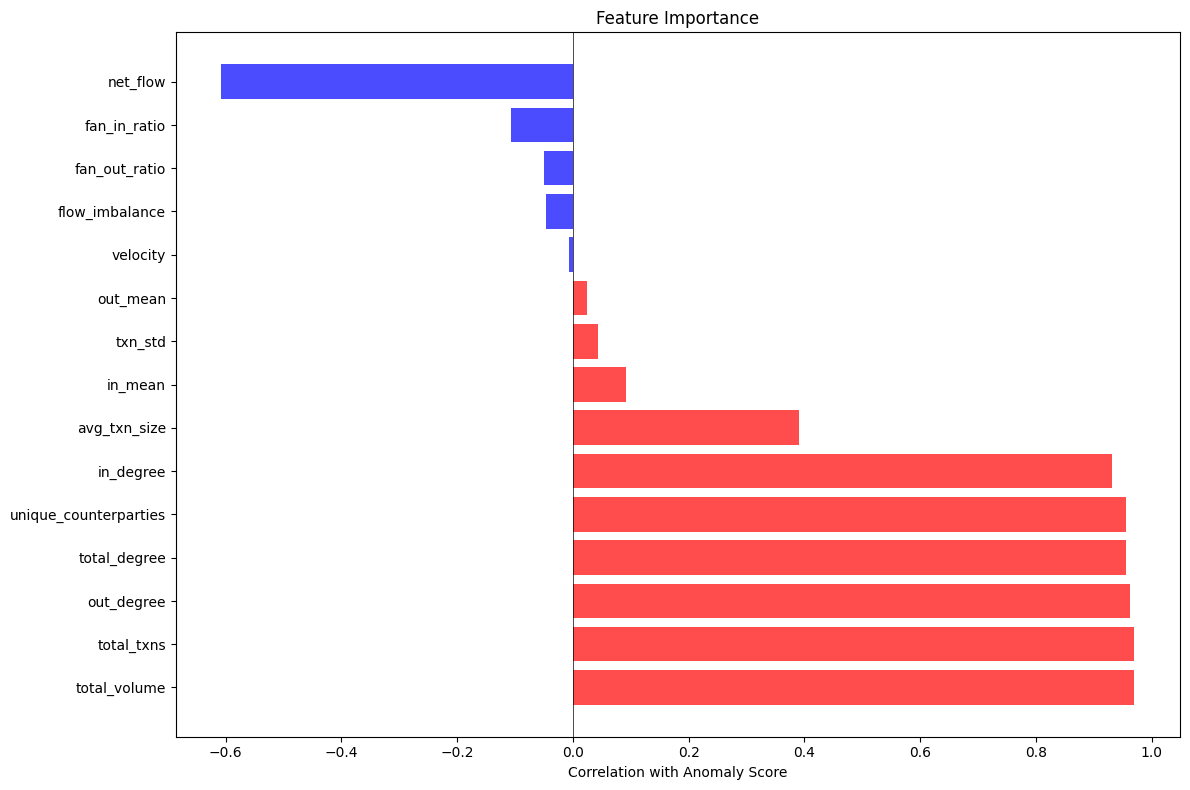

In [9]:
feature_cols = ["total_volume", "avg_txn_size", "out_mean", "in_mean", "txn_std",
                "in_degree", "out_degree", "total_degree", "unique_counterparties",
                "fan_out_ratio", "fan_in_ratio", "flow_imbalance", "net_flow",
                "total_txns", "velocity"]

correlations = []
for feat in feature_cols:
    if feat in node_features.columns:
        corr = node_features[feat].corr(node_features["anomaly_score"])
        correlations.append({"feature": feat, "correlation": corr})

corr_df = pd.DataFrame(correlations).sort_values("correlation", ascending=False)

print("=" * 60)
print(" FEATURE IMPORTANCE (Correlation with Anomaly Score)")
print("=" * 60)
print(corr_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
colors = ["red" if c > 0 else "blue" for c in corr_df["correlation"]]
ax.barh(corr_df["feature"], corr_df["correlation"], color=colors, alpha=0.7)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Correlation with Anomaly Score")
ax.set_title("Feature Importance")
plt.tight_layout()
plt.savefig("results/pattern_feature_importance.png", dpi=150)
plt.show()

## 5. Combined Rule Summary

In [10]:
all_rules = []
for r in rules:
    all_rules.append({**r, "category": "AMOUNT"})
for r in network_rules:
    all_rules.append(r)
for r in freq_rules:
    all_rules.append(r)

all_rules_sorted = sorted(all_rules, key=lambda x: x["suspicious_rate"], reverse=True)

print("=" * 80)
print(" TOP AML DETECTION RULES (Ranked by Suspicious Rate)")
print("=" * 80)
for i, r in enumerate(all_rules_sorted, 1):
    pattern = r.get("pattern", r.get("description", "N/A"))
    print(f"\n{i}. [{r['category']}] {r['rule']}")
    print(f"   Pattern: {pattern}")
    print(f"   Suspicious Rate: {100*r['suspicious_rate']:.1f}%")

# Save rules
rules_output = {
    "total_nodes_analyzed": len(node_features),
    "anomalies_detected": int(node_features["is_anomaly"].sum()),
    "anomaly_threshold": float(threshold),
    "rules": all_rules_sorted,
}
with open("results/aml_rules.json", "w") as f:
    json.dump(rules_output, f, indent=2, default=str)

print(f"\nRules saved to results/aml_rules.json")

 TOP AML DETECTION RULES (Ranked by Suspicious Rate)

1. [AMOUNT] Max outgoing > $1,575
   Pattern: Very large single outgoing transaction
   Suspicious Rate: 10.4%

2. [NETWORK] total_degree > 36
   Pattern: HUB / CENTRAL NODE
   Suspicious Rate: 8.5%

3. [NETWORK] unique_targets > 10
   Pattern: STRUCTURING / LAYERING
   Suspicious Rate: 6.0%

4. [AMOUNT] Avg transaction > $1,078
   Pattern: Large average transaction size
   Suspicious Rate: 5.9%

5. [FREQUENCY] max_repeat_to_same > 3
   Pattern: REPETITIVE BEHAVIOR
   Suspicious Rate: 5.8%

6. [AMOUNT] Total volume > $18,979
   Pattern: High total transaction volume
   Suspicious Rate: 5.6%

7. [NETWORK] unique_sources > 12
   Pattern: COLLECTION / AGGREGATION
   Suspicious Rate: 4.4%

8. [FREQUENCY] total_txns > 34
   Pattern: HIGH ACTIVITY
   Suspicious Rate: 4.2%

9. [AMOUNT] Transaction std > $279
   Pattern: High variance in amounts
   Suspicious Rate: 2.3%

10. [NETWORK] Flow imbalance > 80%
   Pattern: ONE-WAY FLOW
   Suspici

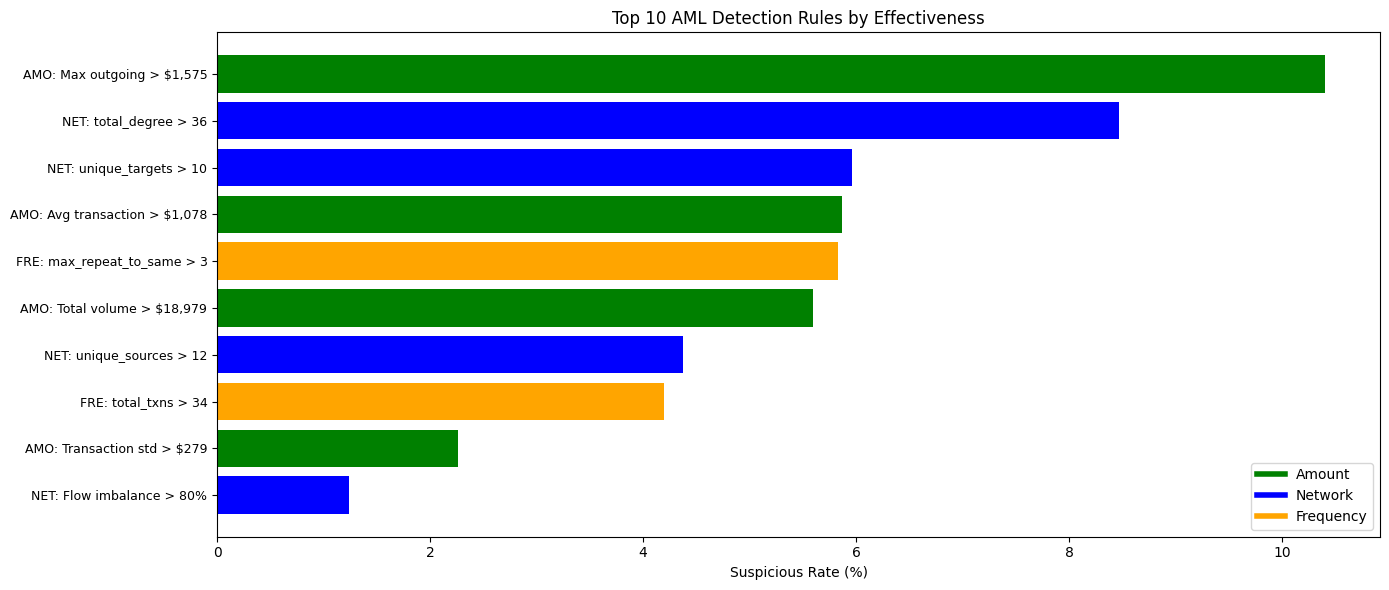


 PATTERN ANALYSIS COMPLETE


In [11]:
# Visual summary
fig, ax = plt.subplots(figsize=(14, 6))
rule_names = [f"{r['category'][:3]}: {r['rule'][:35]}" for r in all_rules_sorted[:10]]
rule_rates = [r["suspicious_rate"] * 100 for r in all_rules_sorted[:10]]
color_map = {"AMO": "green", "NET": "blue", "FRE": "orange"}
bar_colors = [color_map.get(r["category"][:3], "gray") for r in all_rules_sorted[:10]]

ax.barh(range(len(rule_names)), rule_rates, color=bar_colors)
ax.set_yticks(range(len(rule_names)))
ax.set_yticklabels(rule_names, fontsize=9)
ax.set_xlabel("Suspicious Rate (%)")
ax.set_title("Top 10 AML Detection Rules by Effectiveness")
ax.invert_yaxis()
ax.legend(handles=[
    Line2D([0], [0], color="green", lw=4, label="Amount"),
    Line2D([0], [0], color="blue", lw=4, label="Network"),
    Line2D([0], [0], color="orange", lw=4, label="Frequency"),
], loc="lower right")
plt.tight_layout()
plt.savefig("results/pattern_summary.png", dpi=150)
plt.show()

print("\n" + "=" * 60)
print(" PATTERN ANALYSIS COMPLETE")
print("=" * 60)

In [12]:
# ── GPU Cleanup — free VRAM for next notebook ──
import gc
for v in ["G_m", "E_m"]:
    if v in dir():
        exec(f"del {v}")
torch.cuda.empty_cache(); gc.collect()
print(f"GPU freed: {torch.cuda.memory_allocated()/1e6:.1f} MB allocated")

GPU freed: 8.5 MB allocated
